In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib 
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

In [5]:
df = pd.read_csv(r"C:\Users\ELCOT\Desktop\Sasirekha-G40 AIML 7\data\SmartShop_Portfolio_Dataset.csv")

df.head()

,Interaction_ID,Customer_ID,Product_ID,Category,Brand,Age,Gender,Region,Membership,Season,...,Recommendation_Score,Purchase_Status,Product_Rating,Customer_Lifetime_Value,Churn_Risk,Campaign_Response,Device,Payment_Method,Stock_Level,Delivery_Days
0,1,100001,4582,Books,PrimeGear,56,Male,South,Silver,Winter,...,54,0,3.7,138.29,42,1,Mobile,Card,357,7
1,2,100002,8527,Fashion,FreshMart,23,Female,East,Bronze,Summer,...,53,0,4.0,176.18,42,0,Desktop,UPI,437,4
2,3,100003,3677,Toys,FreshMart,35,Male,East,Gold,Spring,...,91,1,4.7,4254.82,7,1,Desktop,UPI,108,10
3,4,100004,5304,Grocery,EcoLife,43,Female,South,Gold,Summer,...,83,1,3.9,3154.76,20,0,Mobile,Card,405,7
4,5,100005,6573,Fashion,BookNest,45,Male,West,Silver,Spring,...,90,1,5.0,3594.27,15,0,Tablet,Wallet,430,9


In [16]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib

# 1. Load your dataset safely using your absolute path
df = pd.read_csv(r"C:\Users\ELCOT\Desktop\Sasirekha-G40 AIML 7\data\SmartShop_Portfolio_Dataset.csv")

# 2. FORCE ALL COLUMN NAMES TO LOWERCASE (This prevents all capitalization KeyErrors!)
df.columns = df.columns.str.strip().str.lower()

# 3. Extract cluster features (now guaranteed to match your lowercase list)
cluster_features = [
    "average_order_value",       
    "customer_lifetime_value",   
    "previous_purchases",        
    "days_since_last_purchase"   
]
X = df[cluster_features].fillna(df[cluster_features].mean())

# 4. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Re-create and train the K-Means model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# 6. Save the trained model file to your absolute path
joblib.dump(kmeans, r"C:\Users\ELCOT\Desktop\Sasirekha-G40 AIML 7\models\kmeans_model.pkl")
print("✅ K-Means model created and saved successfully!")


✅ K-Means model created and saved successfully!


In [21]:
import pandas as pd

# 1. Clean column names to strip spaces and convert to lowercase
df.columns = df.columns.str.strip().str.lower()

# 2. Update feature list to lowercase to match the dataframe perfectly
features = [
    "previous_purchases",
    "average_order_value",
    "recommendation_score",
    "views",
    "time_on_page",
    "customer_lifetime_value",
    "churn_risk"
]

# 3. Safely extract features
X = df[features]
print("✅ Features extracted successfully without errors!")
print(X.head())


✅ Features extracted successfully without errors!
   previous_purchases  average_order_value  recommendation_score  views  \
0                   3                42.54                    54     16   
1                   0               169.16                    53     22   
2                   9               489.93                    91     24   
3                   7               359.15                    83     32   
4                   6               466.64                    90     30   

   time_on_page  customer_lifetime_value  churn_risk  
0           479                   138.29          42  
1            66                   176.18          42  
2            52                  4254.82           7  
3           113                  3154.76          20  
4           532                  3594.27          15  


In [18]:
X.isnull().sum()

average_order_value         0
customer_lifetime_value     0
previous_purchases          0
days_since_last_purchase    0
dtype: int64

In [19]:
X = X.fillna(X.median())

In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
inertia = []

In [23]:
import joblib

joblib.dump(kmeans, r"C:\Users\ELCOT\Desktop\Sasirekha-G40 AIML 7\models\kmeans_model.pkl")
print("✅ K-Means model saved successfully!")

✅ K-Means model saved successfully!


In [24]:
for k in range(2,11):

    model = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

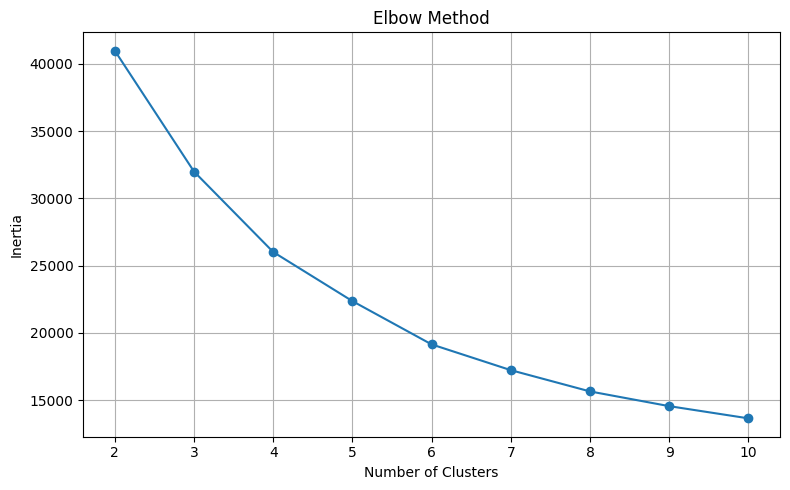

In [25]:
plt.figure(figsize=(8,5))

plt.plot(

    range(2,11),

    inertia,

    marker="o"

)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.tight_layout()

plt.savefig(

    "../outputs/figures/elbow_method.png",

    dpi=300

)

plt.show()

In [26]:
optimal_k = 4

In [27]:
kmeans = KMeans(

    n_clusters=optimal_k,

    random_state=42,

    n_init=10

)

clusters = kmeans.fit_predict(X_scaled)

In [28]:
df["Cluster"] = clusters

In [29]:
score = silhouette_score(

    X_scaled,

    clusters

)

print("Silhouette Score :", score)

Silhouette Score : 0.27152305403812577


In [31]:
import pandas as pd

# 1. Define the EXACT 4 features used during your KMeans training step
cluster_features = [
    "average_order_value",       
    "customer_lifetime_value",   
    "previous_purchases",        
    "days_since_last_purchase"   
]

# 2. Re-run inverse transform using the correct 4-column layout
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=cluster_features
)

# 3. Add a readable Index name for your dashboard analysis
centers.index.name = "Cluster ID"
print("✅ Success! Cluster centers extracted and scaled back to real world values:")
centers


✅ Success! Cluster centers extracted and scaled back to real world values:


,average_order_value,customer_lifetime_value,previous_purchases,days_since_last_purchase
Cluster ID,,,,
0,890.936932,14621.115010,15.840657,182.003439
1,362.700509,2251.949228,5.754603,87.837074
2,1009.216889,4366.187269,3.399292,177.373821
3,381.885505,2237.542937,5.488033,283.230014


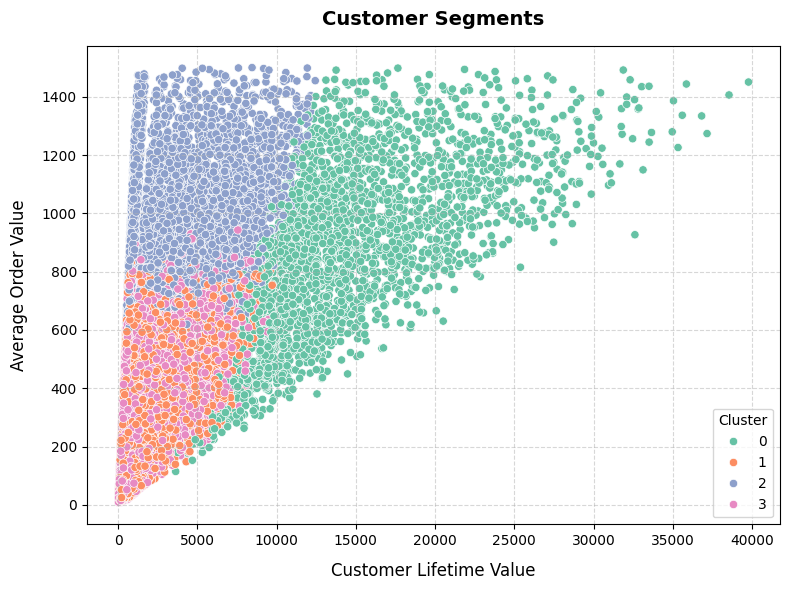

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the drawing space
plt.figure(figsize=(8, 6))

# 2. Draw the scatter plot using the exact lowercase column strings
sns.scatterplot(
    data=df,
    x="customer_lifetime_value",  # Updated to lowercase
    y="average_order_value",     # Updated to lowercase
    hue="Cluster",               # Capitalized if assigned as df["Cluster"]
    palette="Set2"
)

# 3. Clean up the titles and labels
plt.title("Customer Segments", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Customer Lifetime Value", fontsize=12, labelpad=10)
plt.ylabel("Average Order Value", fontsize=12, labelpad=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

# 4. Display the plot
plt.show()


In [36]:
# 1. Update features list to use the exact lowercase columns present in your dataframe
features = [
    "previous_purchases",
    "average_order_value",
    "recommendation_score",
    "views",
    "time_on_page",
    "customer_lifetime_value",
    "churn_risk"
]

# 2. Compute the mean values for each cluster segment safely
cluster_summary = df.groupby("Cluster")[features].mean()

# 3. Add a neat title for better presentation
cluster_summary.index.name = "Cluster ID"
print("✅ Success! Calculated average traits for each customer group:")
cluster_summary

✅ Success! Calculated average traits for each customer group:


,previous_purchases,average_order_value,recommendation_score,views,time_on_page,customer_lifetime_value,churn_risk
Cluster ID,,,,,,,
0,15.840657,890.936932,90.491020,20.648835,318.194498,14621.115010,10.293848
1,5.763728,362.112962,73.621159,20.840806,306.546599,2252.014484,26.608312
2,3.399339,1009.294458,70.805287,20.559122,307.646448,4366.611673,29.360633
3,5.477490,382.839006,72.979406,20.422174,303.750718,2238.562246,27.203065


In [37]:
cluster_summary.to_csv(

    r"C:\Users\ELCOT\Desktop\Sasirekha-G40 AIML 7\outputs\figures\reports\cluster_summary.csv"
)

In [38]:
clusters = kmeans.fit_predict(X_scaled)

In [39]:
df["Cluster"] = clusters